In [1]:
import pandas as pd

ames_housing = pd.read_csv("../datasets/ames_housing_no_missing.csv")
target_name = "SalePrice"
data = ames_housing.drop(columns=target_name)
target = ames_housing[target_name]

In [2]:
numerical_features = [
    "LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2",
    "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF",
    "GrLivArea", "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces",
    "GarageCars", "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch",
    "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal",
]

data_numerical = data[numerical_features]

# First steps

In [3]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

ridge_alpha_0 = make_pipeline(
    StandardScaler(),
    Ridge(alpha=0)
)

cv_ridge_alpha_0 = cross_validate(
    ridge_alpha_0,
    data_numerical,
    target,
    cv=10,
    return_estimator=True
)

C:\Users\Aymen\AppData\Roaming\Python\Python313\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.87857e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\Aymen\AppData\Roaming\Python\Python313\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.43133e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\Aymen\AppData\Roaming\Python\Python313\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.17817e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\Aymen\AppData\Roaming\Python\Python313\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.5879e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


# Q1

In [4]:
coefs_ridge_alpha_0 = [est[-1].coef_ for est in cv_ridge_alpha_0['estimator']]
coefs_ridge_alpha_0_abs = pd.DataFrame(coefs_ridge_alpha_0, columns=numerical_features).abs()
print(f"Largest weight in the α = 0 trained model: {coefs_ridge_alpha_0_abs.max().max()}")

Largest weight in the α = 0 trained model: 1.355204531891317e+19


# Q2

In [5]:
ridge_alpha_default = make_pipeline(
    StandardScaler(),
    Ridge() # default alpha = 1
)

cv_ridge_alpha_default = cross_validate(
    ridge_alpha_default,
    data_numerical,
    target,
    cv=10,
    return_estimator=True
)

In [6]:
coefs_ridge_alpha_default = [est[-1].coef_ for est in cv_ridge_alpha_default['estimator']]
coefs_ridge_alpha_default_abs = pd.DataFrame(coefs_ridge_alpha_default, columns=numerical_features).abs()
print(f"Largest weight in the α = 1 trained model: {coefs_ridge_alpha_default_abs.max().max()}")

Largest weight in the α = 1 trained model: 22562.769198255584


# Q3

In [7]:
df_coefs_ridge_alpha_default_abs = pd.DataFrame(coefs_ridge_alpha_default_abs, columns=numerical_features)

<Axes: >

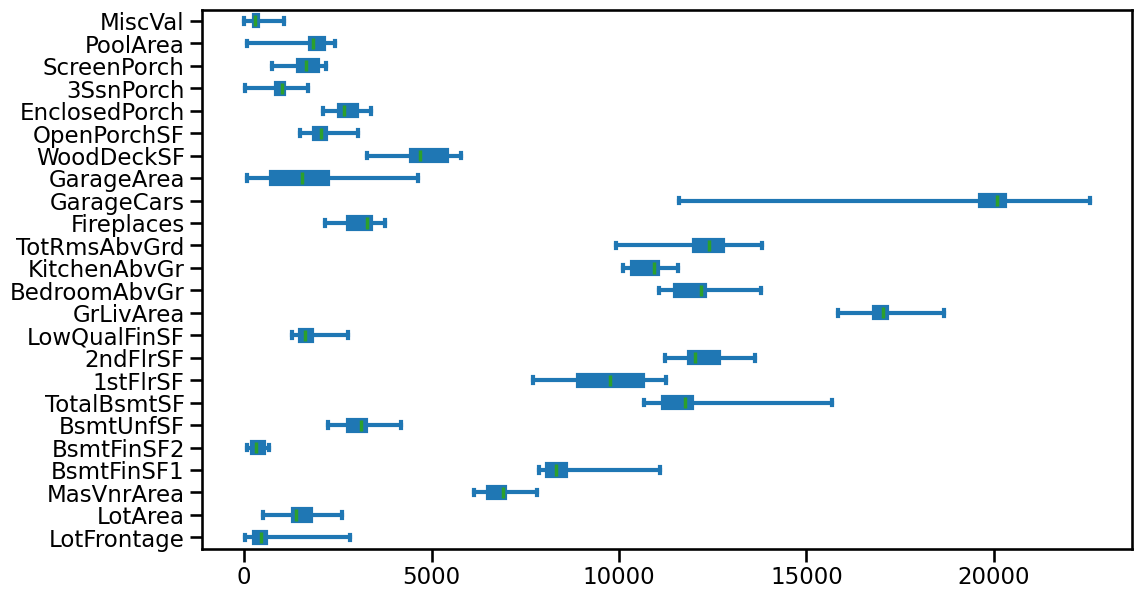

In [8]:
df_coefs_ridge_alpha_default_abs.plot.box(vert=False, figsize=(12, 7))

# Q4

In [9]:
numerical_features_no_garagearea = [
    "LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2",
    "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF",
    "GrLivArea", "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces",
    "GarageCars", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch",
    "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal",
]
data_numerical_no_garagearea = data_numerical[numerical_features_no_garagearea]

Largest weight in the α = 1 trained model: 19963.35113755678


<Axes: >

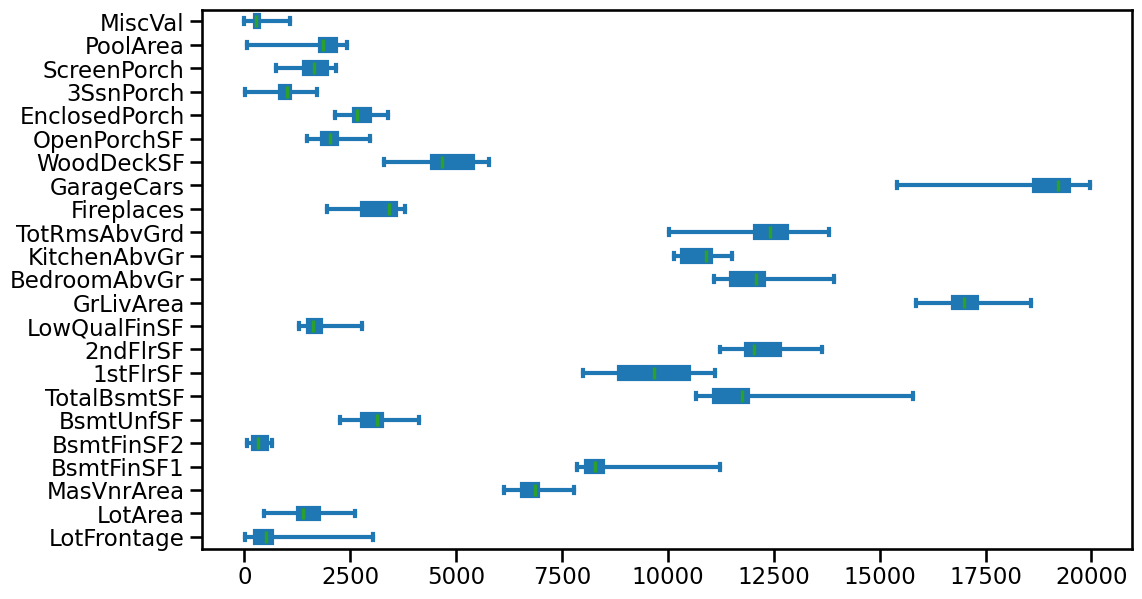

In [10]:
ridge_alpha_default_no_garagearea = make_pipeline(
    StandardScaler(),
    Ridge() # default alpha = 1
)

cv_ridge_alpha_default_no_garagearea = cross_validate(
    ridge_alpha_default_no_garagearea,
    data_numerical_no_garagearea,
    target,
    cv=10,
    return_estimator=True
)

coefs_ridge_alpha_default_no_garagearea = [est[-1].coef_ for est in cv_ridge_alpha_default_no_garagearea['estimator']]
coefs_ridge_alpha_default_abs_no_garagearea = pd.DataFrame(coefs_ridge_alpha_default_no_garagearea, columns=numerical_features_no_garagearea).abs()
print(f"Largest weight in the α = 1 trained model: {coefs_ridge_alpha_default_abs_no_garagearea.max().max()}")

df_coefs_ridge_alpha_default_abs_no_garagearea = pd.DataFrame(coefs_ridge_alpha_default_abs_no_garagearea, columns=numerical_features_no_garagearea)
df_coefs_ridge_alpha_default_abs_no_garagearea.plot.box(vert=False, figsize=(12, 7))

# Q5

In [11]:
data_numerical[["GarageCars", "GarageArea"]]

,GarageCars,GarageArea
0,2,548
1,2,460
2,2,608
3,3,642
4,3,836
...,...,...
1455,2,460
1456,2,500
1457,1,252
1458,1,240


# Q6

Largest weight in the α = 1 trained model: 19963.35113755678


<Axes: >

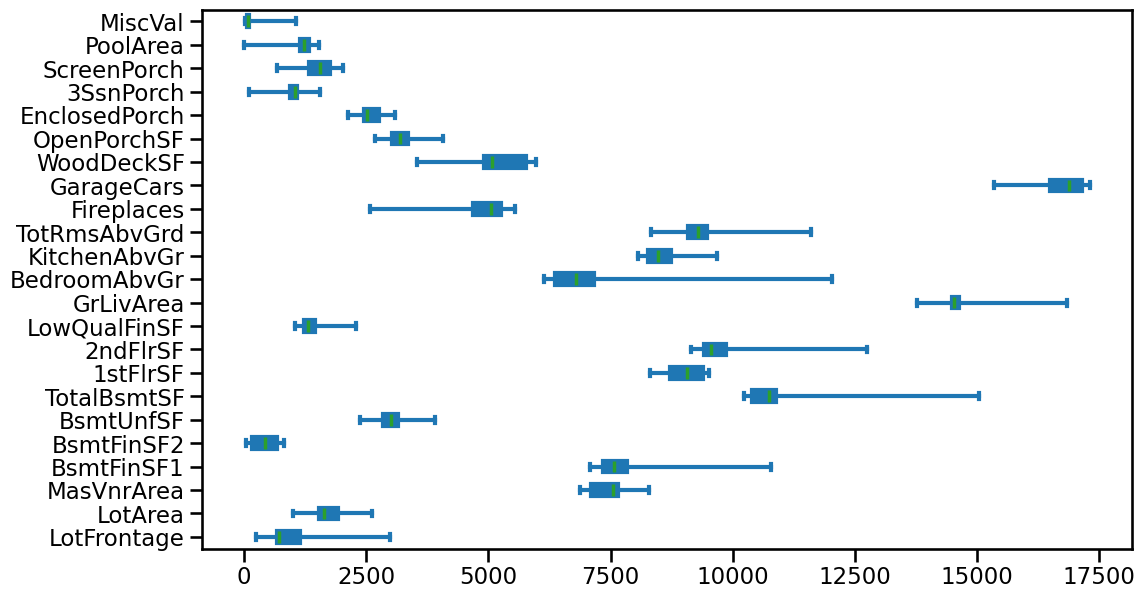

In [12]:
from sklearn.linear_model import RidgeCV
import numpy as np

alphas = np.logspace(-3, 3, num=101)

ridgecv_alpha_default_no_garagearea = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=alphas)
)

cv_ridgecv_alpha_default_no_garagearea = cross_validate(
    ridgecv_alpha_default_no_garagearea,
    data_numerical_no_garagearea,
    target,
    cv=10,
    return_estimator=True
)

coefs_ridgecv_alpha_default_no_garagearea = [est[-1].coef_ for est in cv_ridgecv_alpha_default_no_garagearea['estimator']]
coefs_ridgecv_alpha_default_abs_no_garagearea = pd.DataFrame(coefs_ridgecv_alpha_default_no_garagearea, columns=numerical_features_no_garagearea).abs()
print(f"Largest weight in the α = 1 trained model: {coefs_ridge_alpha_default_abs_no_garagearea.max().max()}")

df_coefs_ridgecv_alpha_default_abs_no_garagearea = pd.DataFrame(coefs_ridgecv_alpha_default_abs_no_garagearea, columns=numerical_features_no_garagearea)
df_coefs_ridgecv_alpha_default_abs_no_garagearea.plot.box(vert=False, figsize=(12, 7))

In [13]:
print(f"σ with α-tuning {df_coefs_ridgecv_alpha_default_abs_no_garagearea['GarageCars'].std()}\nσ without α-tuning {df_coefs_ridge_alpha_default_abs_no_garagearea['GarageCars'].std()}")

σ with α-tuning 587.5476658333662
σ without α-tuning 1305.139394188627


# Q7

In [14]:
for estimator in cv_ridgecv_alpha_default_no_garagearea['estimator']:
    print(estimator[-1].alpha_)

331.13112148259074
331.13112148259074
288.40315031266056
331.13112148259074
331.13112148259074
331.13112148259074
288.40315031266056
331.13112148259074
63.0957344480193
331.13112148259074


# Additional steps

#### Data selection

In [15]:
from sklearn.compose import make_column_selector as selector

categorical_features_selector = selector(dtype_include="object")
numerical_features_selector = selector(dtype_exclude="object")

categorical_features = categorical_features_selector(data)
numerical_features_no_garagearea = numerical_features_selector(data)
numerical_features_no_garagearea.remove("GarageArea")

In [16]:
data_categorical = data[categorical_features]
data_numerical_no_garagearea = data[numerical_features_no_garagearea]

data_no_garagearea = data[numerical_features_no_garagearea + categorical_features]

#### Preprocessor

In [17]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder  

preprocessor = make_column_transformer(
    (OneHotEncoder(handle_unknown="ignore"), categorical_features),
    (StandardScaler(), numerical_features_no_garagearea)
)

In [18]:
ridgecv = make_pipeline(
    preprocessor,
    RidgeCV(alphas=alphas)
)

# Q8

In [20]:
cv_ridgecv_full = cross_validate(
    ridgecv,
    data,
    target,
    cv=10,
    return_estimator=True
)

In [35]:
cv_ridgecv_num = cv_ridgecv_alpha_default_no_garagearea

pd.DataFrame(
    {
        "Ridge Full": cv_ridgecv_full['test_score'], 
        "Ridge Num": cv_ridgecv_num['test_score'],
        "Ridge Full > Ridge Num": cv_ridgecv_full['test_score'] > cv_ridgecv_num['test_score']
    }
)

,Ridge Full,Ridge Num,Ridge Full > Ridge Num
0,0.908022,0.767615,True
1,0.907478,0.796449,True
2,0.897943,0.804622,True
3,0.777927,0.674943,True
4,0.880625,0.776622,True
5,0.887885,0.762680,True
6,0.873230,0.754177,True
7,0.889857,0.709086,True
8,0.579360,0.345969,True
9,0.882966,0.793961,True


#### Non-linear feature engineering steps

In [39]:
from sklearn.preprocessing import SplineTransformer
from sklearn.kernel_approximation import Nystroem

preprocessor_nlfe = make_column_transformer(
    (OneHotEncoder(handle_unknown="ignore"), categorical_features),
    (SplineTransformer(), numerical_features_no_garagearea)
)

ridgecv_nlfe = make_pipeline(
    preprocessor_nlfe,
    Nystroem(kernel="poly", degree=2, n_components=300),
    RidgeCV(alphas=alphas)
)

cv_ridgecv_nlfe = cross_validate(
    ridgecv_nlfe,
    data,
    target,
    cv=10,
    return_estimator=True
)

# Q9

In [42]:
pd.DataFrame(
    {
        "NLFE": cv_ridgecv_nlfe['test_score'], 
        "Simple": cv_ridgecv_full['test_score'],
        "NLFE > Simple": cv_ridgecv_nlfe['test_score'] > cv_ridgecv_full['test_score']
    }
)

,NLFE,Simple,NLFE > Simple
0,0.903468,0.908022,False
1,0.900562,0.907478,False
2,0.912449,0.897943,True
3,0.791343,0.777927,True
4,0.876456,0.880625,False
5,0.907609,0.887885,True
6,0.896543,0.873230,True
7,0.905200,0.889857,True
8,0.789048,0.579360,True
9,0.895320,0.882966,True
